In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

In [3]:
# Number of patients
n = 10000

np.random.seed(42)

data = {
    "Patient_ID": range(1, n+1),
    "Age": np.random.randint(20, 81, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Blood_Pressure": np.random.randint(80, 181, n),
    "Sugar_Level": np.random.randint(70, 201, n),
    "Cholesterol": np.random.randint(150, 301, n),
    "Heart_Rate": np.random.randint(60, 121, n)
}

df = pd.DataFrame(data)

df.head()

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
0,1,58,Female,164,175,234,77
1,2,71,Female,176,70,244,93
2,3,48,Female,103,115,207,77
3,4,34,Male,123,157,201,99
4,5,62,Female,177,91,210,90


In [4]:
# Check structure
df.info()

# Check missing values
df.isnull().sum()

# Basic statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  int64 
 1   Age             10000 non-null  int64 
 2   Gender          10000 non-null  object
 3   Blood_Pressure  10000 non-null  int64 
 4   Sugar_Level     10000 non-null  int64 
 5   Cholesterol     10000 non-null  int64 
 6   Heart_Rate      10000 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 547.0+ KB


,Patient_ID,Age,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,50.290400,129.668100,135.618200,224.568500,89.890900
std,2886.89568,17.588957,29.138093,37.843946,43.604943,17.483803
min,1.00000,20.000000,80.000000,70.000000,150.000000,60.000000
25%,2500.75000,35.000000,104.000000,103.000000,187.000000,75.000000
50%,5000.50000,50.000000,130.000000,136.000000,224.000000,90.000000
75%,7500.25000,66.000000,155.000000,169.000000,262.000000,105.000000
max,10000.00000,80.000000,180.000000,200.000000,300.000000,120.000000


In [5]:
def classify_risk(row):
    score = 0

    if row["Blood_Pressure"] > 140:
        score += 1
    if row["Sugar_Level"] > 160:
        score += 1
    if row["Cholesterol"] > 240:
        score += 1

    if score == 0:
        return "Low"
    elif score == 1:
        return "Medium"
    else:
        return "High"

df["Risk_Level"] = df.apply(classify_risk, axis=1)

df.head()

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Level
0,1,58,Female,164,175,234,77,High
1,2,71,Female,176,70,244,93,High
2,3,48,Female,103,115,207,77,Low
3,4,34,Male,123,157,201,99,Low
4,5,62,Female,177,91,210,90,Medium


In [6]:
high_risk = df[df["Risk_Level"] == "High"]

print("Total High Risk Patients:", len(high_risk))
high_risk.head()

Total High Risk Patients: 3054


,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Level
0,1,58,Female,164,175,234,77,High
1,2,71,Female,176,70,244,93,High
11,12,42,Female,154,179,278,62,High
12,13,30,Male,160,110,286,80,High
14,15,43,Male,92,192,256,114,High


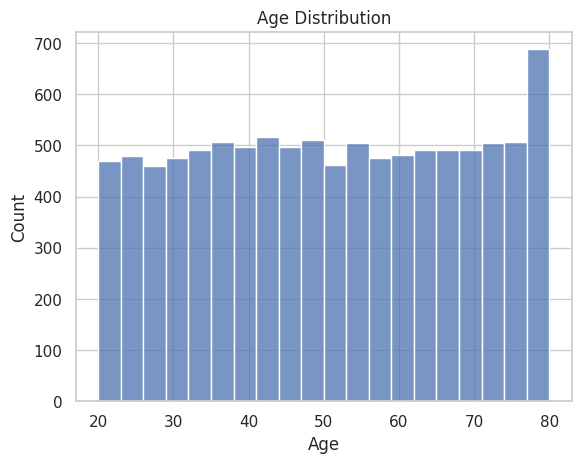

In [7]:
plt.figure()
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

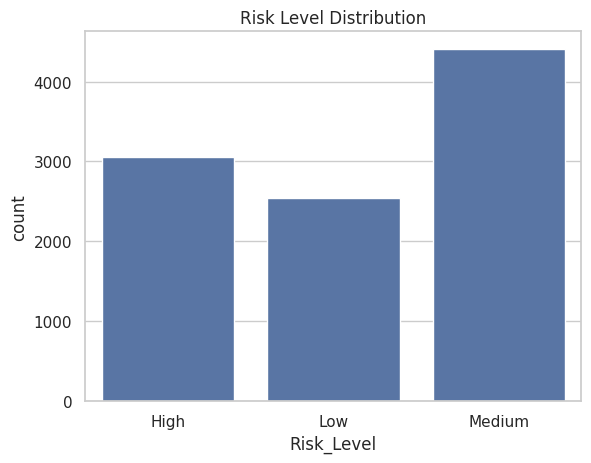

In [8]:
sns.countplot(x="Risk_Level", data=df)
plt.title("Risk Level Distribution")
plt.show()

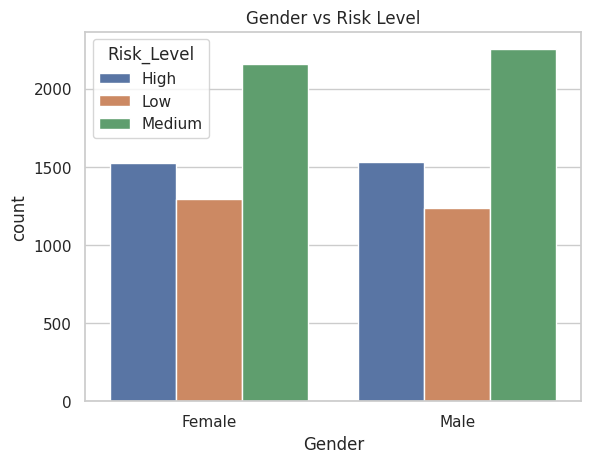

In [9]:
sns.countplot(x="Gender", hue="Risk_Level", data=df)
plt.title("Gender vs Risk Level")
plt.show()

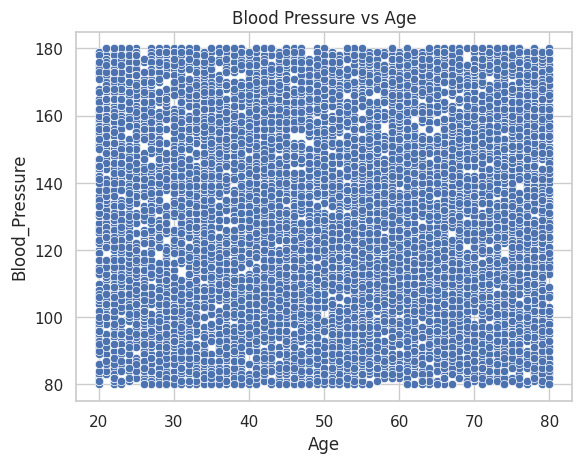

In [10]:
plt.figure()
sns.scatterplot(x="Age", y="Blood_Pressure", data=df)
plt.title("Blood Pressure vs Age")
plt.show()

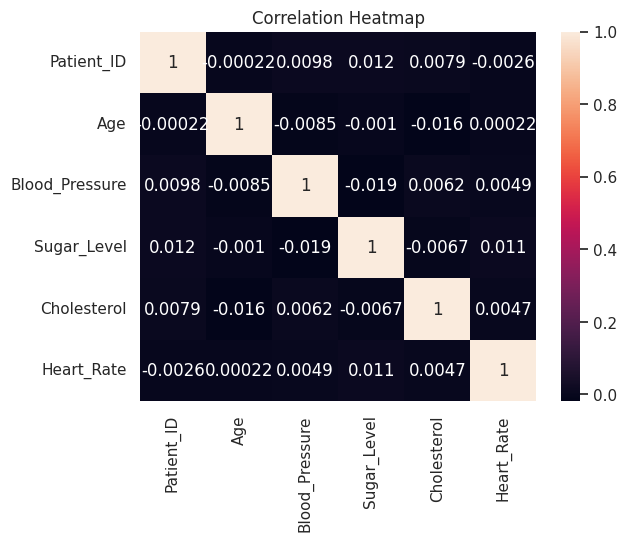

In [11]:
plt.figure()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
df.to_csv("healthcare_data.csv", index=False)

In [13]:
from google.colab import files
files.download("healthcare_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>